In [1]:
import torch
from torch import nn
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
import matplotlib.pyplot as plt

In [2]:

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


In [4]:
transform = transforms.ToTensor()

In [ ]:
import os
import shutil

# Remove the data directory safely using Python
# if os.path.exists("data"):
#     shutil.rmtree("data")

# # Recreate the folders PyTorch needs
# os.makedirs("data/cifar-10-batches-py", exist_ok=True)
# os.makedirs("data/cifar-100-python", exist_ok=True)


In [5]:
datasets.CIFAR10.url = (
    "https://huggingface.co/datasets/xingslong/cifar-10-batches-py/"
    "resolve/main/cifar-10-python.tar.gz"
)

datasets.CIFAR100.url = (
    "https://huggingface.co/datasets/nakroy/cifar100-python/"
    "resolve/main/cifar-100-python.tar.gz"
)
cifar10_train_dataset = datasets.CIFAR10(
    root="data", train=True, download=True, transform=transform
)

cifar10_test_dataset = datasets.CIFAR10(
    root="data", train=False, download=True, transform=transform
)

100%|██████████| 170M/170M [00:01<00:00, 86.8MB/s]


In [6]:
# CIFAR-100

cifar100_train_dataset = datasets.CIFAR100(
    root="data", train=True, download=True, transform=transform
)

cifar100_test_dataset = datasets.CIFAR100(
    root="data", train=False, download=True, transform=transform
)

100%|██████████| 169M/169M [00:11<00:00, 14.7MB/s]


In [7]:
from torch.utils.data import random_split

# Split CIFAR-10
cifar10_train_subset, cifar10_val_subset = random_split(
    cifar10_train_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

# Split CIFAR-100
cifar100_train_subset, cifar100_val_subset = random_split(
    cifar100_train_dataset,
    [45000, 5000],
    generator=torch.Generator().manual_seed(42)
)

In [8]:
batch_size = 64

# CIFAR-10
cifar10_train_loader = DataLoader(
    cifar10_train_subset, batch_size=batch_size, shuffle=True
)

cifar10_val_loader = DataLoader(
    cifar10_val_subset, batch_size=batch_size, shuffle=False
)

cifar10_test_loader = DataLoader(
    cifar10_test_dataset, batch_size=batch_size, shuffle=False
)

# CIFAR-100
cifar100_train_loader = DataLoader(
    cifar100_train_subset, batch_size=batch_size, shuffle=True
)

cifar100_val_loader = DataLoader(
    cifar100_val_subset, batch_size=batch_size, shuffle=False
)

cifar100_test_loader = DataLoader(
    cifar100_test_dataset, batch_size=batch_size, shuffle=False
)

In [9]:
images, labels = next(iter(cifar10_train_loader))

print(images.shape)
print(labels.shape)

torch.Size([64, 3, 32, 32])
torch.Size([64])


In [10]:
labels

tensor([4, 3, 4, 2, 3, 5, 7, 5, 0, 2, 4, 5, 8, 2, 3, 3, 8, 9, 6, 0, 6, 3, 8, 1,
        2, 8, 0, 5, 0, 0, 8, 1, 2, 0, 9, 4, 8, 8, 3, 7, 6, 3, 9, 0, 2, 7, 8, 9,
        3, 1, 7, 5, 0, 0, 9, 5, 2, 0, 3, 9, 2, 6, 2, 5])

In [11]:
class LeNet5(nn.Module):
  def __init__(self, num_classes):
    super().__init__()

    self.features = nn.Sequential(

      nn.Conv2d(3, 6, kernel_size=5),
      nn.Tanh(),

      nn.AvgPool2d(kernel_size=2, stride=2),

      nn.Conv2d(6, 16, kernel_size=5),
      nn.Tanh(),

      nn.AvgPool2d(kernel_size=2, stride=2),

      nn.Conv2d(16, 120, kernel_size=5),
      nn.Tanh()
    )

    self.classifier = nn.Sequential(
      nn.Flatten(),
      nn.Linear(120,84),
      nn.Tanh(),
      nn.Linear(84, num_classes)
    )

  def forward(self, x):
    x = self.features(x)
    x = self.classifier(x)
    return x



In [12]:
class AlexNet(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(3, 96, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(96, 256, kernel_size=5, padding=2),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            nn.Conv2d(256, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 384, kernel_size=3, padding=1),
            nn.ReLU(),

            nn.Conv2d(384, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(256 * 4 * 4, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [13]:
class VGG16(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(64, 64, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 2
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(128, 128, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 3
            nn.Conv2d(128, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(256, 256, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 4
            nn.Conv2d(256, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2),

            # Block 5
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.Conv2d(512, 512, kernel_size=3, padding=1),
            nn.ReLU(),
            nn.MaxPool2d(kernel_size=2, stride=2)
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),

            nn.Linear(512, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(4096, 4096),
            nn.ReLU(),
            nn.Dropout(p=0.5),

            nn.Linear(4096, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

In [14]:
def count_parameters(model):
    return sum(
        parameter.numel()
        for parameter in model.parameters()
        if parameter.requires_grad
    )

In [15]:
for num_classes in [10, 100]:
    print(f"\nCIFAR-{num_classes}")

    for model_class in [LeNet5, AlexNet, VGG16]:
        model = model_class(num_classes=num_classes)

        print(
            f"{model_class.__name__}: "
            f"{count_parameters(model):,} parameters"
        )

        del model


CIFAR-10
LeNet5: 62,006 parameters
AlexNet: 37,323,146 parameters
VGG16: 33,638,218 parameters

CIFAR-100
LeNet5: 69,656 parameters
AlexNet: 37,691,876 parameters
VGG16: 34,006,948 parameters


In [16]:
def train_one_epoch(model, train_loader, criterion, optimizer):
    model.train()

    total_loss = 0
    total_correct = 0
    total_images = 0

    for images, labels in train_loader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)
        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        total_loss += loss.item() * images.size(0)
        total_correct += (outputs.argmax(dim=1) == labels).sum().item()
        total_images += images.size(0)

    epoch_loss = total_loss / total_images
    epoch_accuracy = 100 * total_correct / total_images

    return epoch_loss, epoch_accuracy

In [17]:
def evaluate(model, data_loader, criterion):
    model.eval()

    total_loss = 0
    total_correct = 0
    total_top5_correct = 0
    total_images = 0

    with torch.no_grad():
        for images, labels in data_loader:
            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)
            loss = criterion(outputs, labels)

            total_loss += loss.item() * images.size(0)

            predictions = outputs.argmax(dim=1)
            total_correct += (predictions == labels).sum().item()

            top5_predictions = outputs.topk(5, dim=1).indices
            top5_correct = (
                top5_predictions == labels.unsqueeze(1)
            ).any(dim=1)

            total_top5_correct += top5_correct.sum().item()
            total_images += images.size(0)

    average_loss = total_loss / total_images
    accuracy = 100 * total_correct / total_images
    top5_accuracy = 100 * total_top5_correct / total_images

    return average_loss, accuracy, top5_accuracy

In [18]:
import time

def fit(model, train_loader, val_loader, epochs, learning_rate):
    model = model.to(device)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(), lr=learning_rate
    )

    history = {
        "train_loss": [],
        "train_accuracy": [],
        "val_loss": [],
        "val_accuracy": [],
        "train_time": []
    }

    for epoch in range(epochs):
        if device.type == "cuda":
            torch.cuda.synchronize()

        start_time = time.perf_counter()

        train_loss, train_accuracy = train_one_epoch(
            model, train_loader, criterion, optimizer
        )

        if device.type == "cuda":
            torch.cuda.synchronize()

        train_time = time.perf_counter() - start_time

        val_loss, val_accuracy, _ = evaluate(
            model, val_loader, criterion
        )

        history["train_loss"].append(train_loss)
        history["train_accuracy"].append(train_accuracy)
        history["val_loss"].append(val_loss)
        history["val_accuracy"].append(val_accuracy)
        history["train_time"].append(train_time)

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train loss: {train_loss:.4f} | "
            f"Train accuracy: {train_accuracy:.2f}% | "
            f"Val loss: {val_loss:.4f} | "
            f"Val accuracy: {val_accuracy:.2f}% | "
            f"Training time: {train_time:.1f}s"
        )

    return history

In [19]:
lenet_cifar10 = LeNet5(num_classes=10).to(device)

lenet_cifar10_history = fit(
    model=lenet_cifar10,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    epochs=1,
    learning_rate=0.001
)

Epoch 1/1 | Train loss: 1.8466 | Train accuracy: 33.36% | Val loss: 1.7190 | Val accuracy: 38.80% | Training time: 8.7s


In [20]:
vgg16_cifar10 = VGG16(num_classes=10).to(device)

vgg16_trial_history = fit(
    model=vgg16_cifar10,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    epochs=1,
    learning_rate=0.001
)

Epoch 1/1 | Train loss: 2.3037 | Train accuracy: 10.20% | Val loss: 2.3030 | Val accuracy: 9.42% | Training time: 11.6s


In [21]:
alexnet_cifar10 = AlexNet(num_classes=10).to(device)

alexnet_trial_history = fit(
    model=alexnet_cifar10,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    epochs=3,
    learning_rate=0.001
)

Epoch 1/3 | Train loss: 1.8240 | Train accuracy: 31.15% | Val loss: 1.4860 | Val accuracy: 45.32% | Training time: 10.5s
Epoch 2/3 | Train loss: 1.3985 | Train accuracy: 48.90% | Val loss: 1.3167 | Val accuracy: 52.14% | Training time: 10.5s
Epoch 3/3 | Train loss: 1.2296 | Train accuracy: 55.71% | Val loss: 1.1928 | Val accuracy: 57.32% | Training time: 10.5s


In [22]:
vgg16_cifar10 = VGG16(num_classes=10).to(device)

vgg16_trial_history = fit(
    model=vgg16_cifar10,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    epochs=3,
    learning_rate=0.001
)

Epoch 1/3 | Train loss: 2.3039 | Train accuracy: 9.74% | Val loss: 2.3027 | Val accuracy: 10.24% | Training time: 11.4s
Epoch 2/3 | Train loss: 2.3035 | Train accuracy: 9.78% | Val loss: 2.3030 | Val accuracy: 9.76% | Training time: 11.4s
Epoch 3/3 | Train loss: 2.3029 | Train accuracy: 9.90% | Val loss: 2.3030 | Val accuracy: 9.42% | Training time: 11.3s


In [23]:
vgg16_cifar10 = VGG16(num_classes=10).to(device)

vgg16_trial_history = fit(
    model=vgg16_cifar10,
    train_loader=cifar10_train_loader,
    val_loader=cifar10_val_loader,
    epochs=3,
    learning_rate=0.0001
)

Epoch 1/3 | Train loss: 2.1756 | Train accuracy: 14.07% | Val loss: 1.9015 | Val accuracy: 24.20% | Training time: 11.5s
Epoch 2/3 | Train loss: 1.7893 | Train accuracy: 27.98% | Val loss: 1.6319 | Val accuracy: 36.28% | Training time: 11.3s
Epoch 3/3 | Train loss: 1.5954 | Train accuracy: 37.49% | Val loss: 1.5000 | Val accuracy: 40.52% | Training time: 11.4s



Starting LeNet5_CIFAR10
Epoch 1/20 | Train loss: 2.0717 | Train accuracy: 23.73% | Val loss: 1.9474 | Val accuracy: 30.12% | Training time: 7.7s
Epoch 2/20 | Train loss: 1.8929 | Train accuracy: 32.28% | Val loss: 1.8512 | Val accuracy: 33.98% | Training time: 7.6s
Epoch 3/20 | Train loss: 1.8248 | Train accuracy: 34.91% | Val loss: 1.8017 | Val accuracy: 36.10% | Training time: 7.7s
Epoch 4/20 | Train loss: 1.7855 | Train accuracy: 36.66% | Val loss: 1.7705 | Val accuracy: 37.58% | Training time: 7.7s
Epoch 5/20 | Train loss: 1.7563 | Train accuracy: 37.57% | Val loss: 1.7447 | Val accuracy: 38.56% | Training time: 7.7s
Epoch 6/20 | Train loss: 1.7322 | Train accuracy: 38.66% | Val loss: 1.7251 | Val accuracy: 38.74% | Training time: 7.6s
Epoch 7/20 | Train loss: 1.7062 | Train accuracy: 39.54% | Val loss: 1.7065 | Val accuracy: 39.60% | Training time: 7.7s
Epoch 8/20 | Train loss: 1.6809 | Train accuracy: 40.41% | Val loss: 1.6814 | Val accuracy: 40.68% | Training time: 7.6s
Epoch 9

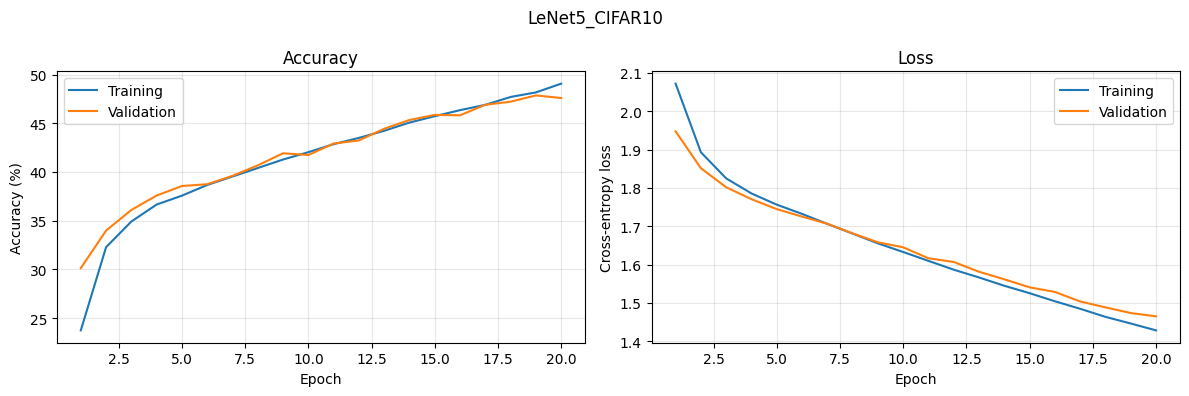

Test accuracy: 48.41%
Accuracy drop: 51.59%

Starting AlexNet_CIFAR10
Epoch 1/20 | Train loss: 1.7132 | Train accuracy: 35.04% | Val loss: 1.3873 | Val accuracy: 48.52% | Training time: 10.5s
Epoch 2/20 | Train loss: 1.2744 | Train accuracy: 53.34% | Val loss: 1.1347 | Val accuracy: 59.74% | Training time: 10.5s
Epoch 3/20 | Train loss: 1.0670 | Train accuracy: 61.71% | Val loss: 1.0163 | Val accuracy: 63.36% | Training time: 10.4s
Epoch 4/20 | Train loss: 0.9251 | Train accuracy: 67.03% | Val loss: 0.9874 | Val accuracy: 65.08% | Training time: 10.4s
Epoch 5/20 | Train loss: 0.8010 | Train accuracy: 71.85% | Val loss: 0.8175 | Val accuracy: 70.92% | Training time: 10.5s
Epoch 6/20 | Train loss: 0.6955 | Train accuracy: 75.60% | Val loss: 0.7428 | Val accuracy: 73.08% | Training time: 10.5s
Epoch 7/20 | Train loss: 0.6014 | Train accuracy: 78.94% | Val loss: 0.7342 | Val accuracy: 74.06% | Training time: 10.5s
Epoch 8/20 | Train loss: 0.5169 | Train accuracy: 82.02% | Val loss: 0.6895 

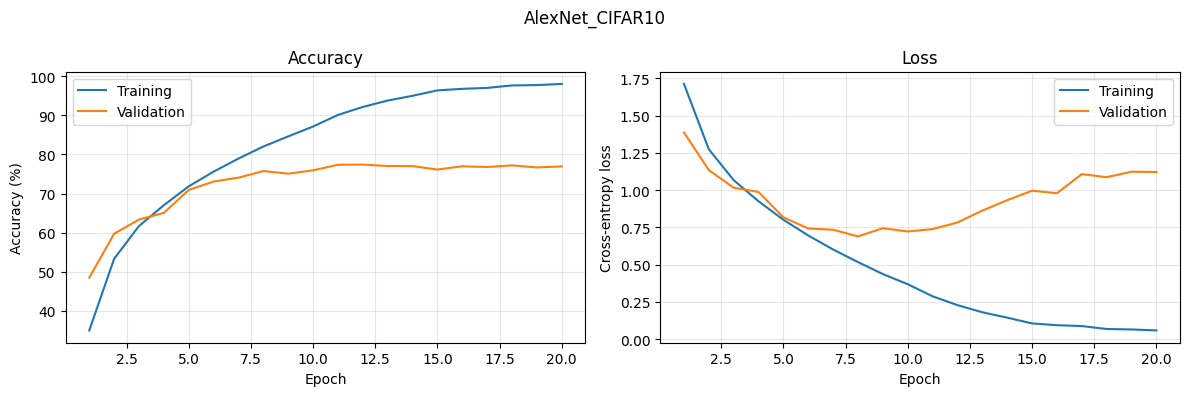

Test accuracy: 76.53%
Accuracy drop: 23.47%

Starting VGG16_CIFAR10
Epoch 1/20 | Train loss: 2.3001 | Train accuracy: 10.27% | Val loss: 2.1407 | Val accuracy: 16.80% | Training time: 11.4s
Epoch 2/20 | Train loss: 1.8990 | Train accuracy: 23.53% | Val loss: 1.7825 | Val accuracy: 28.46% | Training time: 11.4s
Epoch 3/20 | Train loss: 1.6677 | Train accuracy: 33.61% | Val loss: 1.5633 | Val accuracy: 38.22% | Training time: 11.4s
Epoch 4/20 | Train loss: 1.5163 | Train accuracy: 40.98% | Val loss: 1.4527 | Val accuracy: 44.26% | Training time: 11.5s
Epoch 5/20 | Train loss: 1.3697 | Train accuracy: 48.20% | Val loss: 1.3198 | Val accuracy: 52.08% | Training time: 11.4s
Epoch 6/20 | Train loss: 1.2113 | Train accuracy: 55.33% | Val loss: 1.1818 | Val accuracy: 57.24% | Training time: 11.3s
Epoch 7/20 | Train loss: 1.0679 | Train accuracy: 61.22% | Val loss: 1.1311 | Val accuracy: 59.00% | Training time: 11.3s
Epoch 8/20 | Train loss: 0.9431 | Train accuracy: 66.43% | Val loss: 0.9427 | 

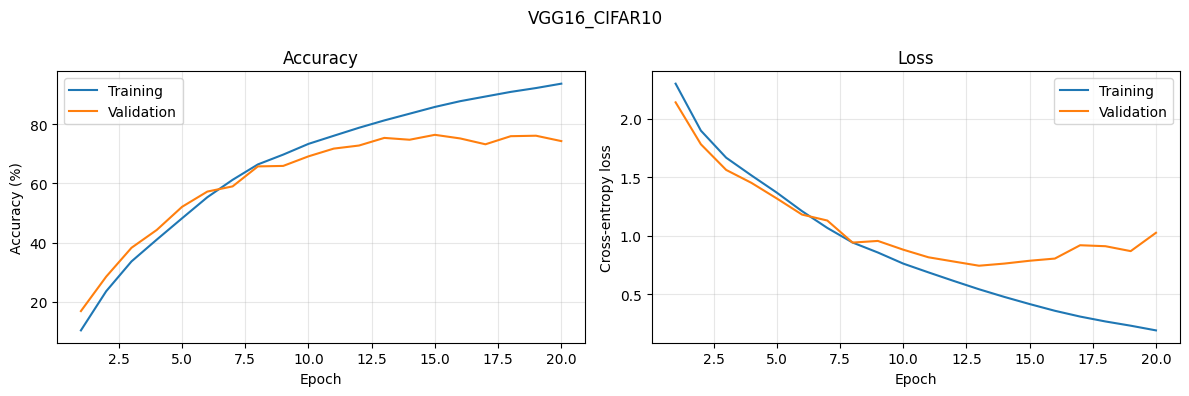

Test accuracy: 73.45%
Accuracy drop: 26.55%

Starting LeNet5_CIFAR100
Epoch 1/20 | Train loss: 4.4519 | Train accuracy: 2.72% | Val loss: 4.2882 | Val accuracy: 4.20% | Training time: 7.7s
Epoch 2/20 | Train loss: 4.2087 | Train accuracy: 5.82% | Val loss: 4.1163 | Val accuracy: 7.58% | Training time: 7.7s
Epoch 3/20 | Train loss: 4.0561 | Train accuracy: 8.39% | Val loss: 3.9915 | Val accuracy: 9.20% | Training time: 7.7s
Epoch 4/20 | Train loss: 3.9544 | Train accuracy: 10.21% | Val loss: 3.9100 | Val accuracy: 11.30% | Training time: 7.7s
Epoch 5/20 | Train loss: 3.8821 | Train accuracy: 11.50% | Val loss: 3.8477 | Val accuracy: 12.92% | Training time: 7.7s
Epoch 6/20 | Train loss: 3.8245 | Train accuracy: 12.55% | Val loss: 3.8021 | Val accuracy: 12.78% | Training time: 7.8s
Epoch 7/20 | Train loss: 3.7788 | Train accuracy: 13.30% | Val loss: 3.7575 | Val accuracy: 13.56% | Training time: 7.7s
Epoch 8/20 | Train loss: 3.7419 | Train accuracy: 13.85% | Val loss: 3.7299 | Val accurac

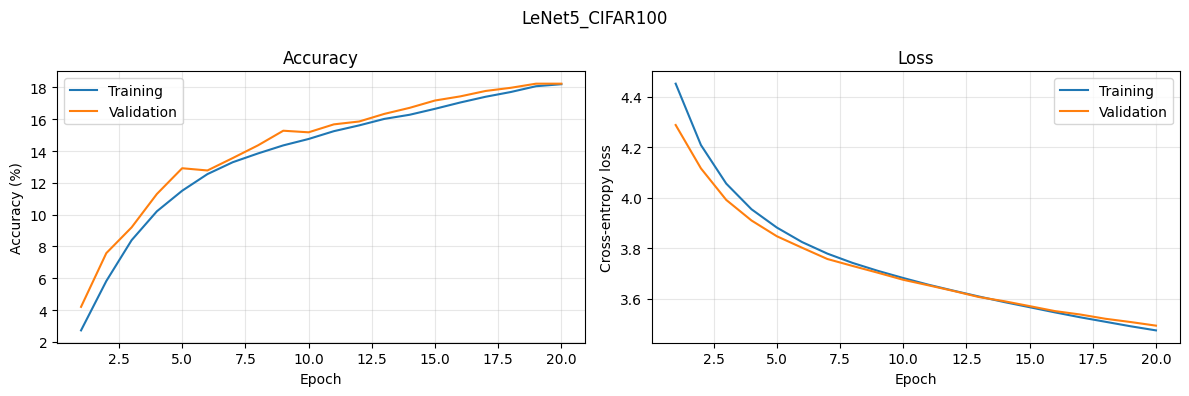

Test accuracy: 17.43%
Accuracy drop: 82.57%
Test top-5 accuracy: 42.79%

Starting AlexNet_CIFAR100
Epoch 1/20 | Train loss: 4.2391 | Train accuracy: 4.34% | Val loss: 3.8442 | Val accuracy: 9.98% | Training time: 10.5s
Epoch 2/20 | Train loss: 3.6538 | Train accuracy: 12.85% | Val loss: 3.3809 | Val accuracy: 18.20% | Training time: 10.5s
Epoch 3/20 | Train loss: 3.2597 | Train accuracy: 20.11% | Val loss: 3.0753 | Val accuracy: 24.08% | Training time: 10.5s
Epoch 4/20 | Train loss: 2.9816 | Train accuracy: 25.24% | Val loss: 2.8704 | Val accuracy: 29.16% | Training time: 10.5s
Epoch 5/20 | Train loss: 2.7469 | Train accuracy: 30.00% | Val loss: 2.6947 | Val accuracy: 32.02% | Training time: 10.5s
Epoch 6/20 | Train loss: 2.5450 | Train accuracy: 34.19% | Val loss: 2.5050 | Val accuracy: 35.74% | Training time: 10.5s
Epoch 7/20 | Train loss: 2.3572 | Train accuracy: 38.20% | Val loss: 2.4188 | Val accuracy: 37.54% | Training time: 10.5s
Epoch 8/20 | Train loss: 2.1869 | Train accuracy:

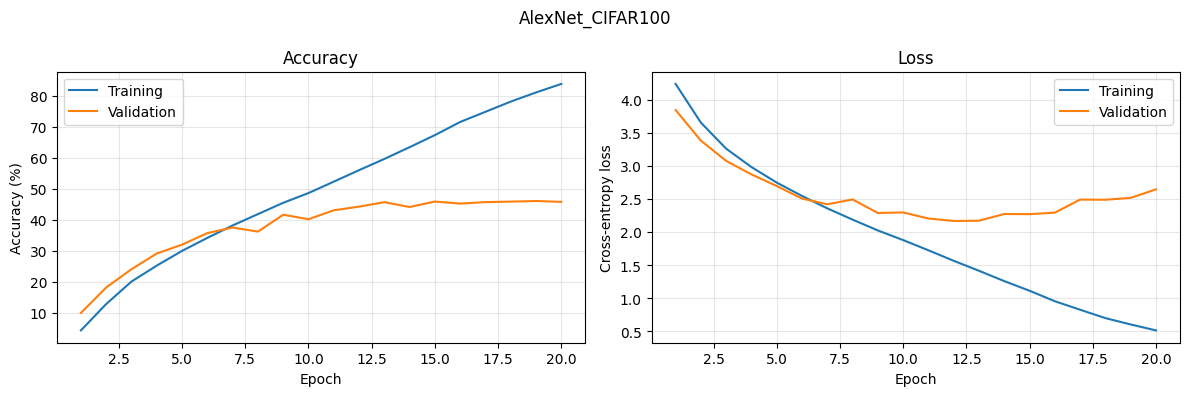

Test accuracy: 46.96%
Accuracy drop: 53.04%
Test top-5 accuracy: 74.94%

Starting VGG16_CIFAR100
Epoch 1/20 | Train loss: 4.6066 | Train accuracy: 0.83% | Val loss: 4.6058 | Val accuracy: 0.96% | Training time: 11.5s
Epoch 2/20 | Train loss: 4.6058 | Train accuracy: 0.98% | Val loss: 4.6059 | Val accuracy: 0.96% | Training time: 11.3s
Epoch 3/20 | Train loss: 4.6057 | Train accuracy: 0.94% | Val loss: 4.6059 | Val accuracy: 0.86% | Training time: 11.4s
Epoch 4/20 | Train loss: 4.6055 | Train accuracy: 0.95% | Val loss: 4.6059 | Val accuracy: 0.74% | Training time: 11.4s
Epoch 5/20 | Train loss: 4.6055 | Train accuracy: 0.99% | Val loss: 4.6060 | Val accuracy: 0.92% | Training time: 11.3s
Epoch 6/20 | Train loss: 4.6055 | Train accuracy: 0.96% | Val loss: 4.6059 | Val accuracy: 0.92% | Training time: 11.4s
Epoch 7/20 | Train loss: 4.6054 | Train accuracy: 0.97% | Val loss: 4.6060 | Val accuracy: 0.74% | Training time: 11.4s
Epoch 8/20 | Train loss: 4.6054 | Train accuracy: 0.93% | Val l

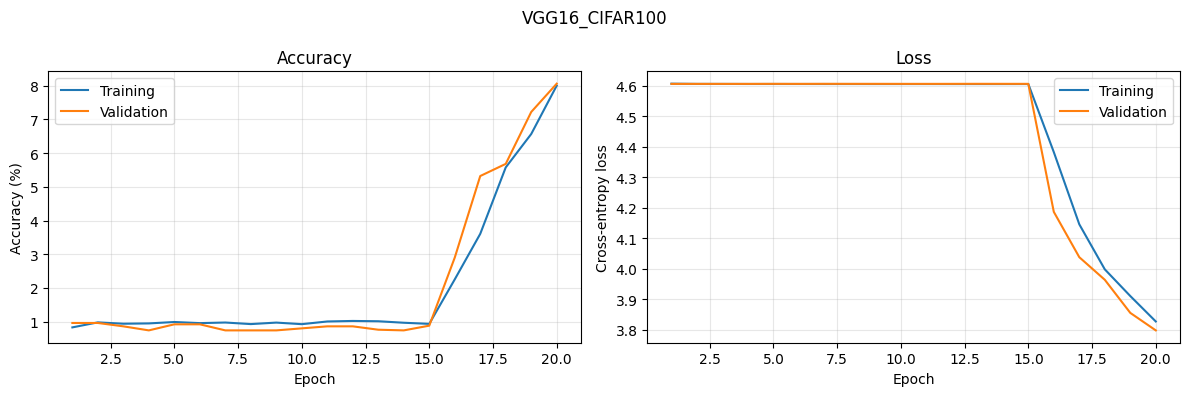

Test accuracy: 8.10%
Accuracy drop: 91.90%
Test top-5 accuracy: 28.86%

All six experiments completed.


,model,dataset,epochs,learning_rate,batch_size,optimizer,parameters,test_loss,test_accuracy,test_top5_accuracy,accuracy_drop,mean_epoch_time_seconds
0,LeNet5,CIFAR10,20,0.0001,64,Adam,62006,1.441207,48.41,NaN,51.59,7.649268
1,AlexNet,CIFAR10,20,0.0001,64,Adam,37323146,1.207422,76.53,NaN,23.47,10.474343
2,VGG16,CIFAR10,20,0.0001,64,Adam,33638218,1.096198,73.45,NaN,26.55,11.354173
3,LeNet5,CIFAR100,20,0.0001,64,Adam,69656,3.519248,17.43,42.79,82.57,7.707451
4,AlexNet,CIFAR100,20,0.0001,64,Adam,37691876,2.593657,46.96,74.94,53.04,10.515983
5,VGG16,CIFAR100,20,0.0001,64,Adam,34006948,3.828528,8.10,28.86,91.90,11.396667


In [24]:
import os
import pandas as pd
import matplotlib.pyplot as plt

os.makedirs("results", exist_ok=True)

epochs = 20
learning_rate = 0.0001
criterion = nn.CrossEntropyLoss()

model_classes = {
    "LeNet5": LeNet5,
    "AlexNet": AlexNet,
    "VGG16": VGG16
}

dataset_loaders = {
    "CIFAR10": (
        cifar10_train_loader,
        cifar10_val_loader,
        cifar10_test_loader,
        10
    ),
    "CIFAR100": (
        cifar100_train_loader,
        cifar100_val_loader,
        cifar100_test_loader,
        100
    )
}

results = []

for dataset_name, loaders in dataset_loaders.items():
    train_loader, val_loader, test_loader, num_classes = loaders

    for model_name, model_class in model_classes.items():
        experiment_name = f"{model_name}_{dataset_name}"
        print(f"\nStarting {experiment_name}")

        # Start each experiment with fresh weights.
        torch.manual_seed(42)
        if torch.cuda.is_available():
            torch.cuda.manual_seed_all(42)

        model = model_class(num_classes=num_classes).to(device)

        # Train and validate.
        history = fit(
            model=model,
            train_loader=train_loader,
            val_loader=val_loader,
            epochs=epochs,
            learning_rate=learning_rate
        )

        # Evaluate once on the test set.
        test_loss, test_accuracy, test_top5 = evaluate(
            model, test_loader, criterion
        )

        results.append({
            "model": model_name,
            "dataset": dataset_name,
            "epochs": epochs,
            "learning_rate": learning_rate,
            "batch_size": train_loader.batch_size,
            "optimizer": "Adam",
            "parameters": count_parameters(model),
            "test_loss": test_loss,
            "test_accuracy": test_accuracy,
            "test_top5_accuracy": (
                test_top5 if num_classes == 100 else None
            ),
            "accuracy_drop": 100 - test_accuracy,
            "mean_epoch_time_seconds": (
                sum(history["train_time"]) / len(history["train_time"])
            )
        })

        # Save results after each completed experiment.
        pd.DataFrame(history).to_csv(
            f"results/{experiment_name}_history.csv",
            index=False
        )

        pd.DataFrame(results).to_csv(
            "results/summary.csv",
            index=False
        )

        torch.save(
            model.state_dict(),
            f"results/{experiment_name}.pth"
        )

        # Plot training versus validation accuracy and loss.
        epoch_numbers = range(1, len(history["train_loss"]) + 1)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))

        axes[0].plot(
            epoch_numbers, history["train_accuracy"], label="Training"
        )
        axes[0].plot(
            epoch_numbers, history["val_accuracy"], label="Validation"
        )
        axes[0].set_title("Accuracy")
        axes[0].set_ylabel("Accuracy (%)")

        axes[1].plot(
            epoch_numbers, history["train_loss"], label="Training"
        )
        axes[1].plot(
            epoch_numbers, history["val_loss"], label="Validation"
        )
        axes[1].set_title("Loss")
        axes[1].set_ylabel("Cross-entropy loss")

        for ax in axes:
            ax.set_xlabel("Epoch")
            ax.legend()
            ax.grid(alpha=0.3)

        fig.suptitle(experiment_name)
        fig.tight_layout()
        fig.savefig(
            f"results/{experiment_name}_curves.png",
            dpi=150
        )

        plt.show()
        plt.close(fig)

        print(f"Test accuracy: {test_accuracy:.2f}%")
        print(f"Accuracy drop: {100 - test_accuracy:.2f}%")

        if num_classes == 100:
            print(f"Test top-5 accuracy: {test_top5:.2f}%")

        del model
        if torch.cuda.is_available():
            torch.cuda.empty_cache()

print("\nAll six experiments completed.")
display(pd.DataFrame(results))

In [25]:
import shutil
from google.colab import files

shutil.make_archive("lab2_results", "zip", "results")
files.download("lab2_results.zip")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
summary = pd.read_csv("results/summary.csv")

display(summary[[
    "model",
    "dataset",
    "test_accuracy",
    "test_top5_accuracy",
    "accuracy_drop",
    "mean_epoch_time_seconds"
]].round(2))

,model,dataset,test_accuracy,test_top5_accuracy,accuracy_drop,mean_epoch_time_seconds
0,LeNet5,CIFAR10,48.41,NaN,51.59,7.65
1,AlexNet,CIFAR10,76.53,NaN,23.47,10.47
2,VGG16,CIFAR10,73.45,NaN,26.55,11.35
3,LeNet5,CIFAR100,17.43,42.79,82.57,7.71
4,AlexNet,CIFAR100,46.96,74.94,53.04,10.52
5,VGG16,CIFAR100,8.10,28.86,91.90,11.40


In [ ]:
print ("h")